In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]], columns=['cgpa','resume_score','package'])
df

,cgpa,resume_score,package
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [4]:
def innitialize_parameter(layer_dim):
    np.random.seed(19)
    parameters = {}
    L = len(layer_dim)

    for i in range(1,L): # starts with 1 because layer 0 is input layer does not have weight and biases
        parameters['w'+str(i)] = np.ones((layer_dim[i-1], layer_dim[i]))*0.1   # no of rowa , no of col, innitial val
        parameters['b'+str(i)] = np.zeros((layer_dim[i], 1))
    
    return parameters


In [ ]:
"""
layer_dims = [3, 5, 2]

W1 = (3,5)
W2 = (5,2)

W1 =
[0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1]
 
"""

In [5]:
parameters = innitialize_parameter([3,5,2])

In [6]:
parameters['w1']

array([[0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1]])

In [7]:
parameters['b1']

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [ ]:
"""
layer_dims = [3, 5, 2]

W1 = (3,5)
W2 = (5,2)

W1 =
[0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.1]
 
"""

In [8]:
# layer_dims = [3, 5, 2]

def forward_propogation(X,parameters): # X = Input layer

    A = X
    L = len(parameters) // 2 # 4 w1,b1,w2,b2

    for i in range(1,L+1): # 1,2,3,4
        A_prev = A
        w = parameters['w'+str(i)]
        b = parameters['b'+str(i)]

        

        print('A'+str(i-1)+': \n', A_prev)
        print('w'+str(i)+': \n', w)
        print('b'+str(i)+': \n', b)
        print('--'*10)

        A = np.dot(w.T,A_prev) + b   # performs summation operations
        print('A'+str(i)+': \n', A)
        print('--'*20)
    
    return A,A_prev

## Example

In [7]:
X = df[['cgpa','resume_score']].values[0].reshape(2,1)
X

array([[8],
       [8]])

In [9]:
Y = df[['package']].values[0][0]
Y

np.int64(4)

In [10]:
# innitializing parameters
parameters = innitialize_parameter([2,2,1])
parameters

{'w1': array([[0.1, 0.1],
        [0.1, 0.1]]),
 'b1': array([[0.],
        [0.]]),
 'w2': array([[0.1],
        [0.1]]),
 'b2': array([[0.]])}

In [25]:
Y_hat,A1 = forward_propogation(X,parameters)

A0: 
 [[8]
 [8]]
w1: 
 [[0.1 0.1]
 [0.1 0.1]]
b1: 
 [[0.]
 [0.]]
--------------------
A1: 
 [[1.6]
 [1.6]]
----------------------------------------
A1: 
 [[1.6]
 [1.6]]
w2: 
 [[0.1]
 [0.1]]
b2: 
 [[0.]]
--------------------
A2: 
 [[0.32]]
----------------------------------------


In [28]:
Y_hat = Y_hat[0][0]

In [29]:
(Y-Y_hat)**2 # error for the first datapoint

np.float64(13.542399999999997)

## Backpropagation

In [84]:
def update_parameters(parameters, y, y_hat, A1, X):
    lr = 0.001
    error = (y - y_hat)

    # ----- Layer 2 -----
    parameters['w2'][0][0] += lr * 2 * error * A1[0][0]
    parameters['w2'][1][0] += lr * 2 * error * A1[1][0]

    parameters['b2'][0][0] += lr * 2 * error

    # ----- Layer 1 -----
    parameters['w1'][0][0] += lr * 2 * error * parameters['w2'][0][0] * X[0][0]
    parameters['w1'][0][1] += lr * 2 * error * parameters['w2'][0][0] * X[1][0]

    parameters['w1'][1][0] += lr * 2 * error * parameters['w2'][1][0] * X[0][0]
    parameters['w1'][1][1] += lr * 2 * error * parameters['w2'][1][0] * X[1][0]

    parameters['b1'][0][0] += lr * 2 * error * parameters['w2'][0][0]
    parameters['b1'][1][0] += lr * 2 * error * parameters['w2'][1][0]

    return parameters

## running through the whole dataset

In [ ]:
epoches = 20
np.random.seed(19)
parameters = innitialize_parameter([2,2,1])
# print(parameters)
avg_loss = []

X = df[['cgpa','resume_score']].values
Y = df[['package']].values

for i in range(epoches):

    total_loss = 0
    # print(f"{i+1} - iteration")
    # print('--'*20)
    for j in range(X.shape[0]):

        # randomly select any one of the 4 data-rows
        row_num = np.random.randint(0,X.shape[0])

        # define X and Y
        X_data = X[row_num].reshape(2,1)
        Y_data = Y[row_num][0]

        # forward propagation
        Y_hat,a1 = forward_propogation(X_data,parameters)
        Y_hat = Y_hat[0][0]

        # loss calculation
        loss = (Y_data-Y_hat)**2
        total_loss += loss
        # print(loss)

        # update weights and bias
        update_parameters(parameters,Y_data,Y_hat,a1,X_data)
        # print(parameters)
        # print('--'*10+'\n')

    # calculate the average loss
    avg_loss.append(total_loss/X.shape[0])

In [86]:
avg_loss

[np.float64(25.36769884750222),
 np.float64(18.182694370992415),
 np.float64(12.486196667160707),
 np.float64(3.1702104256644135),
 np.float64(1.9504977768855194),
 np.float64(1.9115231034940905),
 np.float64(0.8510782422892262),
 np.float64(1.2949780167087828),
 np.float64(0.795924821442648),
 np.float64(0.9402501596792647),
 np.float64(1.2037970479166888),
 np.float64(0.8659801766355222),
 np.float64(0.8531389474579196),
 np.float64(1.2240062967378476),
 np.float64(0.8132800093522689),
 np.float64(1.1848958316233296),
 np.float64(1.5989612972613678),
 np.float64(1.4120892828996352),
 np.float64(0.8933690742522056),
 np.float64(2.434207025996854)]

In [28]:
import matplotlib.pyplot as plt

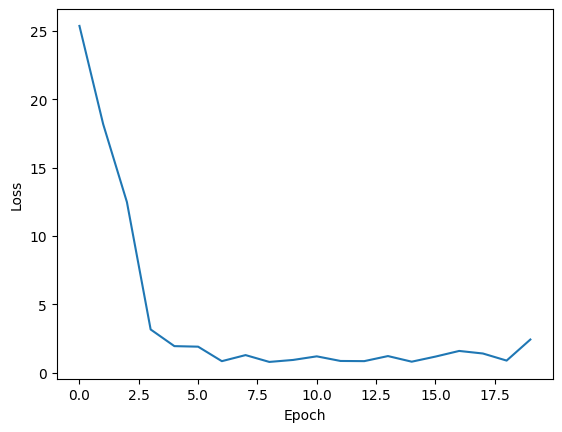

In [87]:
plt.plot(avg_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## using Keras

In [73]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [74]:
model = Sequential([
    Input(shape=(2,)),
    Dense(2, activation='linear'),
    Dense(1, activation='linear')
])

In [75]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [76]:
model.get_weights()

[array([[ 0.9840771 ,  0.8072969 ],
        [-0.29514682,  0.4004004 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.81967324],
        [-0.15942669]], dtype=float32),
 array([0.], dtype=float32)]

In [77]:
new_weights = [np.array([[0.1,  0.1 ],
        [ 0.1, 0.1]], dtype=np.float32),
 np.array([0., 0.], dtype=np.float32),
 np.array([[0.1],
        [0.1]], dtype=np.float32),
 np.array([0.], dtype=np.float32)]

In [78]:
model.set_weights(new_weights)

In [79]:
model.get_weights()

[array([[0.1, 0.1],
        [0.1, 0.1]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.1],
        [0.1]], dtype=float32),
 array([0.], dtype=float32)]

In [80]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mean_squared_error', optimizer=optimizer)

In [81]:
history = model.fit(df.iloc[:, 0:-1], df.iloc[:, -1], epochs=75, verbose=1, batch_size=1)

# verbose:
# Controls how much training information Keras prints during model.fit()

# verbose = 0 → no output (silent)
# verbose = 1 → progress bar + loss per batch/epoch (default)
# verbose = 2 → one line per epoch (clean output)

# Example:
# model.fit(..., verbose=1)


# batch_size:
# Number of training samples processed before updating weights

# batch_size = 1 → Stochastic Gradient Descent (update after every sample)
# batch_size = N (all samples) → Batch Gradient Descent (1 update per epoch)
# batch_size = small number (e.g., 2, 4, 32) → Mini-batch Gradient Descent

# Example:
# If dataset has 4 samples:
# batch_size = 1 → 4 updates per epoch
# batch_size = 4 → 1 update per epoch

# Tradeoff:
# Small batch → faster but noisy updates
# Large batch → stable but slower updates

# For very small datasets (like yours), using batch_size = total samples is usually better

Epoch 1/75


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.8980  
Epoch 2/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27.5899 
Epoch 3/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.2518 
Epoch 4/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.9287 
Epoch 5/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.5544 
Epoch 6/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.2070 
Epoch 7/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.8405 
Epoch 8/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.4498 
Epoch 9/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25.0538 
Epoch 10/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.6624 
Epoch 11/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.2759 
Epoch 12/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.8149 
Epoch 13/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.4184 
Epoch 14/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.9616 
Epoch 15/75
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.4591 
Epoch 16/75
4/4 ━━━━━━━━━━━━━

In [82]:
model.get_weights()

[array([[0.373364  , 0.373364  ],
        [0.36526725, 0.36526725]], dtype=float32),
 array([0.27200764, 0.27200764], dtype=float32),
 array([[0.37259647],
        [0.37259647]], dtype=float32),
 array([0.20452753], dtype=float32)]

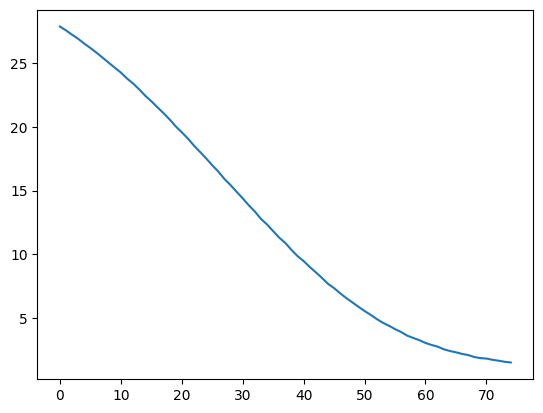

In [83]:
plt.plot(history.history['loss'])